# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

17

In [3]:
reports_paths.sort_values(ascending=False).head()

9     data/cash_app_report_1783357451480.csv
16    data/cash_app_report_1783012238287.csv
0     data/cash_app_report_1782999354380.csv
7     data/cash_app_report_1782913510031.csv
1     data/cash_app_report_1782826607723.csv
dtype: object

In [4]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1783357451480.csv')

In [5]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-06 12:44:23 EDT,NaN,Bitcoin Sell,USD,$10.00,-$0.20,$9.80,BTC,"$63,170.74",0.000158,COMPLETE,sale of BTC 0.00015830,NaN,Cash Balance
1,2026-07-06 12:42:10 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,AAPL,$312.61,0.031980,COMPLETE,$10 Purchase of Apple,NaN,Cash Balance
2,2026-07-06 12:41:54 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$76.31,0.131040,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance
3,2026-07-06 12:40:39 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,PLTR,$133.27,0.075030,COMPLETE,$10 Purchase of Palantir Technologies,NaN,Cash Balance
4,2026-07-06 12:39:05 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,ORCL,$143.78,0.069540,COMPLETE,$10 Purchase of Oracle,NaN,Cash Balance
5,2026-07-06 12:38:52 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,DELL,$410.94,0.024330,COMPLETE,$10 Purchase of Dell Technologies,NaN,Cash Balance
6,2026-07-06 00:00:00 EDT,NaN,Stock Dividends,USD,$0.04,$0.00,$0.04,BIV,NaN,NaN,COMPLETE,$0.04 Dividend from Vanguard Intermediate Term...,NaN,Cash Balance
7,2026-07-06 00:00:00 EDT,NaN,Stock Dividends,USD,$0.07,$0.00,$0.07,JEPI,NaN,NaN,COMPLETE,$0.07 Dividend from JPMorgan Equity Premium In...,NaN,Cash Balance
8,2026-07-06 00:00:00 EDT,NaN,Stock Dividends,USD,$0.05,$0.00,$0.05,BNDX,NaN,NaN,COMPLETE,$0.05 Dividend from Vanguard Total Internation...,NaN,Cash Balance
9,2026-07-06 00:00:00 EDT,NaN,Stock Dividends,USD,$0.04,$0.00,$0.04,VTEB,NaN,NaN,COMPLETE,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF,NaN,Cash Balance


In [6]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
114,2026-06-22 09:30:20 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$237.13,0.04217,COMPLETE,$10 Sale of Dick's Sporting Goods,NaN,Cash Balance
175,2026-06-16 11:45:45 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$868.45,0.01151,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
101,2026-06-22 13:16:52 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$33.58,0.29775,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
59,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
20,2026-07-02 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$778.00,0.01285,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
148,2026-06-18 13:09:36 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,VNQ,$96.10,0.10405,COMPLETE,$10 Sale of Vanguard Real Estate ETF,NaN,Cash Balance
299,2026-06-04 09:30:07 EDT,NaN,NaN,USD,$10.21,$0.00,$10.21,OWL,$9.79,1.04329,COMPLETE,$10.21 Sale of Blue Owl Capital,NaN,Cash Balance
15,2026-07-02 13:07:21 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,V,$358.68,0.05575,COMPLETE,$20 Sale of Visa,NaN,Cash Balance
26,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
105,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance


In [7]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.000158
1      0.031980
2      0.131040
3      0.075030
4      0.069540
         ...   
672         NaN
673         NaN
674         NaN
675         NaN
676         NaN
Name: Asset Amount, Length: 677, dtype: float64

In [8]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
673,2025-08-22 16:07:20+00:00,0.0,0.0,NaN,0.00000,NaN,NaN,Account Notifications,USD,NaN,Cash Balance,COMPLETE,New device login,NaN
586,2026-05-30 15:58:33+00:00,100.0,100.0,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
446,2026-06-03 13:30:13+00:00,-1.0,-1.0,254.40,0.00393,0.0,AMZN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Amazon,NaN
349,2026-06-03 19:25:59+00:00,-25.0,-25.0,25.63,0.97549,0.0,AMX,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of America Movil,NaN
291,2026-06-04 13:30:17+00:00,-10.0,-10.0,164.22,0.06089,0.0,COIN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Coinbase,NaN
188,2026-06-16 13:31:37+00:00,-5.0,-5.0,220.89,0.02263,0.0,MS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Morgan Stanley,NaN
157,2026-06-18 14:10:24+00:00,-5.0,-5.0,83.79,0.05967,0.0,WFC,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Wells Fargo,NaN
149,2026-06-18 17:09:02+00:00,-10.0,-10.0,126.88,0.07881,0.0,VONG,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Russell 1000 Growth ETF,NaN
113,2026-06-22 13:30:20+00:00,-10.0,-10.0,297.85,0.03357,0.0,AAPL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Apple,NaN
101,2026-06-22 17:16:52+00:00,10.0,10.0,33.58,0.29775,0.0,HIMS,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Hims & Hers Health,NaN


In [9]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
670,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
671,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
672,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
674,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
675,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
676,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


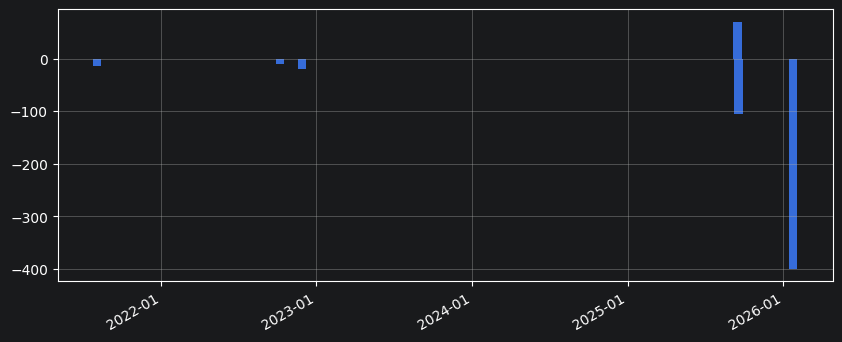

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [11]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,677.000000,677.000000,549.000000,677.00000,674.000000
mean,0.072555,0.082659,4101.480765,0.14142,-0.010148
std,37.673675,37.671787,16075.653806,0.33321,0.055210
min,-400.000000,-400.000000,2.220000,0.00000,-0.500000
25%,-10.000000,-10.000000,56.850000,0.00798,0.000000
50%,-10.000000,-10.000000,133.220000,0.04464,0.000000
75%,-1.000000,-1.000000,305.000000,0.12709,0.000000
max,200.000000,200.000000,80346.140000,4.50917,0.000000


In [12]:
data.nunique().sort_values(ascending=False)

asset_price     540
asset_amount    536
date            531
notes           392
asset_type      167
amount           60
net_amount       59
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [13]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      31
XYZ      13
JPM      12
ORCL     11
META     11
WFC      11
V        10
MCD      10
AMZN     10
PZZA     10
DELL      8
MSFT      8
GOOG      8
VONV      8
GOOGL     8
UBER      8
NFLX      7
VMBS      7
FISV      7
HOOD      7
DOW       7
AAPL      6
INTU      6
PYPL      6
VOO       6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

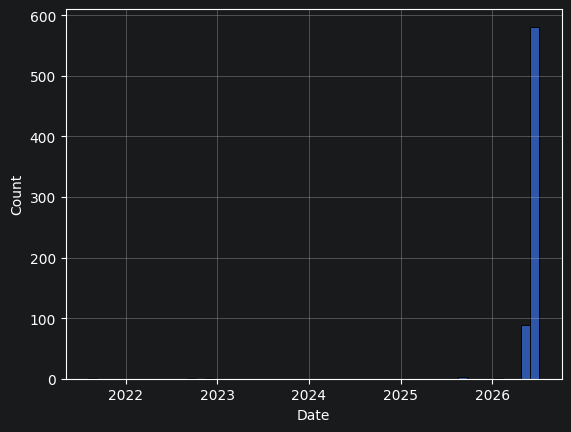

In [14]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [15]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-04-14,2026-05-27,2026-05-29,2026-06-02,2026-06-03,2026-06-16,2026-07-01,2026-07-01,2026-07-06


In [16]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,31,-156.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,13,-171.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
META,11,-80.95,"(-10.0, -5.0, -1.0, 0.05)",4
WFC,11,-51.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
ORCL,11,-95.00,"(-10.0, -5.0)",2
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
V,10,-81.00,"(-25.0, -20.0, -10.0, -5.0, -1.0, 20.0)",6
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4


In [17]:
data['currency'].value_counts()

currency
USD    677
Name: count, dtype: int64

In [18]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    472
Deposits                      65
Stock Sell                    46
Stock Dividends               41
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   7
P2P                            6
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [19]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,7,472,41,46,590
BTC,24,7,0,0,0,31
XYZ,0,0,12,0,1,13
JPM,0,0,10,0,2,12
WFC,0,0,9,0,2,11
META,0,0,10,1,0,11
ORCL,0,0,11,0,0,11
AMZN,0,0,10,0,0,10
PZZA,0,0,9,0,1,10


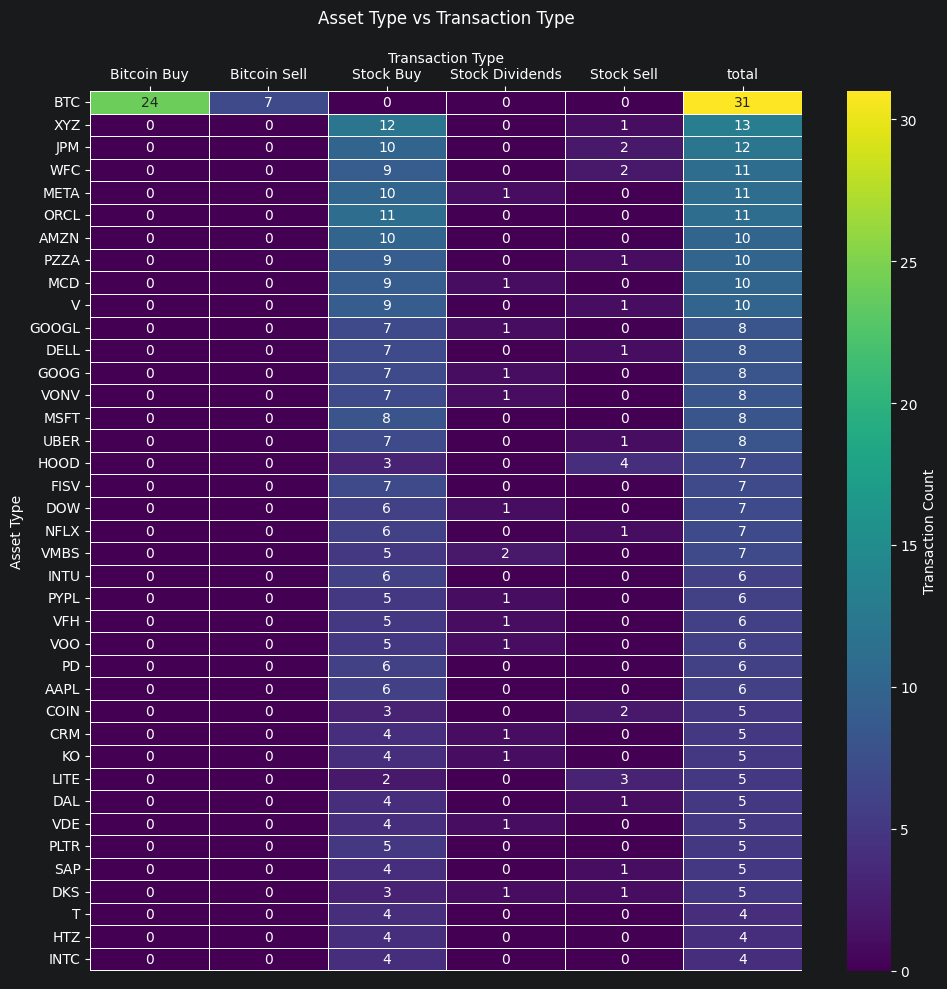

In [20]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [21]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
0,2026-07-06 16:44:23+00:00,9.8,10.0,63170.74,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
12,2026-07-02 17:10:19+00:00,19.6,20.0,61217.07,0.000327,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN
40,2026-07-01 14:21:49+00:00,-10.0,-9.8,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN
77,2026-06-26 17:38:10+00:00,-5.0,-4.9,60331.07,0.000081,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00008122,NaN
132,2026-06-20 20:54:15+00:00,9.8,10.0,63371.65,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN


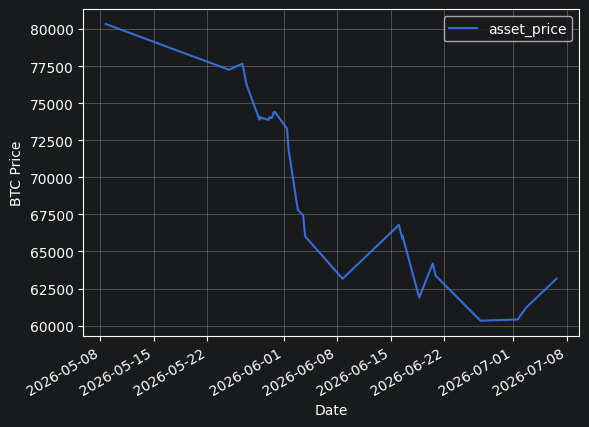

In [22]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [23]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell     7
Name: count, dtype: int64

In [24]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.0
Bitcoin Sell,88.2


In [25]:
data_btc['net_amount'].sum()

np.float64(-163.8)

In [26]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001434
Name: asset_amount, dtype: float64

In [27]:
data_btc['asset_amount'].sum()

np.float64(0.00485381)

In [28]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00198543)

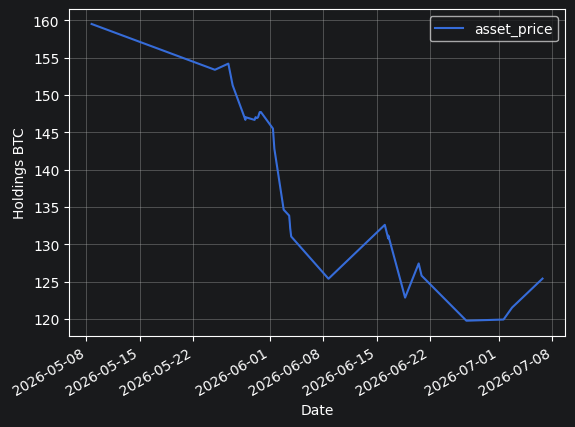

In [29]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [30]:
data_btc['asset_price'] * data_btc['asset_amount']

0       9.999928
12     20.000229
40      9.800290
77      4.900090
132    10.000046
134     4.899747
143    19.999846
225     5.000156
226     4.999899
229     4.900240
265    19.999798
345     9.799846
372     9.800287
396     0.980144
493     9.800221
504     0.979969
521     9.799652
579     4.900136
581     9.799865
584     4.900112
585     9.799903
589     9.799965
593    24.500200
600    24.499951
604    24.500084
623     9.799731
627     9.800031
650    24.499991
667     9.799898
668     4.900356
669     9.799819
dtype: float64

In [31]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
76,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
105,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
187,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
232,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
280,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
356,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
368,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
381,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
419,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
422,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN


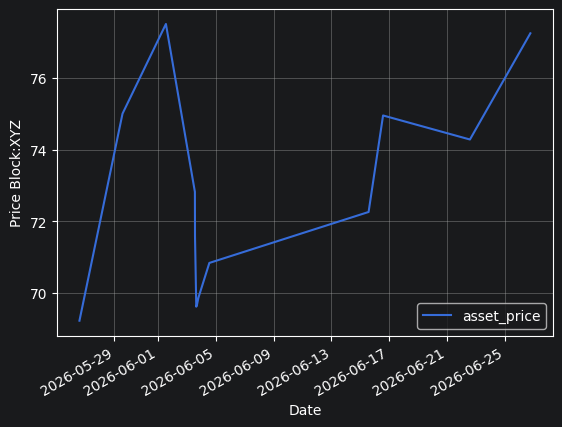

In [32]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [33]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     31
XYZ     13
JPM     12
META    11
WFC     11
        ..
UNFI     1
UNH      1
EWY      1
ABNB     1
ZG       1
Name: amount, Length: 167, dtype: int64

In [34]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [35]:
data['asset_amount'].describe()

count    677.00000
mean       0.14142
std        0.33321
min        0.00000
25%        0.00798
50%        0.04464
75%        0.12709
max        4.50917
Name: asset_amount, dtype: float64

In [36]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 15:12:32+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000,41.665912,9.686363,27.762524,0.0,99.663815,0.000000,9.953370,0.000000,0.000000
2026-05-27 13:30:01+00:00,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-15 13:30:08+00:00,28.691891,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-06-15 13:30:24+00:00,28.691891,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-06-02 19:54:00+00:00,10.217560,0.000000,0.000000,9.9981,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,0.000000,19.992722,0.0,93.073427,0.000000,0.000000,0.000000,0.000000
2026-07-06 16:44:23+00:00,61.309073,9.999493,16.180396,9.9981,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,55.498870,23.724046,37.761938,0.0,181.056739,52.997013,19.954137,9.999727,9.999925
2026-06-04 13:30:15+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-06-22 13:30:02+00:00,28.691891,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,14.039852,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,40.190894,19.954137,9.999727,9.999925
2026-07-02 14:54:10+00:00,51.311805,9.999493,16.180396,9.9981,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,55.498870,23.724046,37.761938,0.0,181.056739,52.997013,19.954137,9.999727,9.999925


In [37]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3750.5851740000003)

In [38]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-06 16:39:05+00:00,0.013681,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:40:39+00:00,0.013681,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:41:54+00:00,0.013681,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:42:10+00:00,0.016347,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:44:23+00:00,0.016347,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666


In [39]:
asset_price_rel.iloc[-1].describe()

count    167.000000
mean       0.005988
std        0.007300
min        0.000000
25%        0.002154
50%        0.004032
75%        0.006809
max        0.048274
Name: 2026-07-06 16:44:23+00:00, dtype: float64

In [40]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.048274
AMZN    0.039891
DELL    0.027591
MCD     0.026132
UBER    0.025640
Name: 2026-07-06 16:44:23+00:00, dtype: float64

In [41]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-06 16:39:05+00:00,0.013681,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:40:39+00:00,0.013681,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:41:54+00:00,0.013681,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:42:10+00:00,0.016347,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666
2026-07-06 16:44:23+00:00,0.016347,0.002666,0.004314,0.002666,0.0,0.002666,0.0,0.005613,0.002411,0.008017,...,0.00183,0.014797,0.006325,0.010068,0.0,0.048274,0.01413,0.00532,0.002666,0.002666


In [42]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-18 17:15:27+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-24 13:30:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 13:31:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-02 17:10:19+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-02 13:30:09+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:08:51+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:32:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,72.26,NaN,NaN,NaN,NaN


In [43]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-18 17:15:27+00:00,1.018386,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-24 13:30:02+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.072945,1.005550,0.995338,1.0,1.0
2026-06-22 13:31:02+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,1.005550,0.995338,1.0,1.0
2026-06-16 13:30:10+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-07-02 17:10:19+00:00,0.950374,1.0,0.719207,1.0,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.075766,0.995338,1.0,1.0
2026-07-02 13:30:09+00:00,0.950374,1.0,0.719207,1.0,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.075766,0.995338,1.0,1.0
2026-06-03 15:08:51+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.955619,1.0,1.034089,1.000000,1.000000,1.0,1.0
2026-05-27 13:30:01+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.0
2026-06-15 13:32:07+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

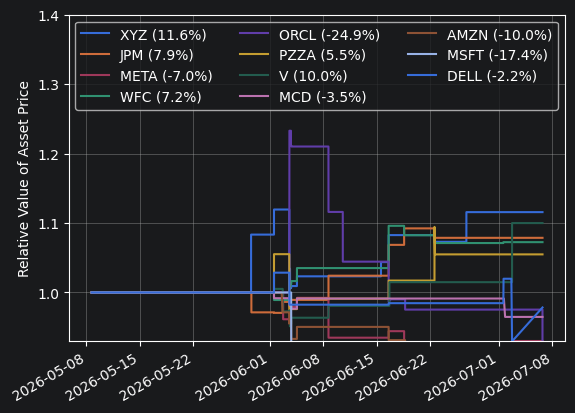

In [44]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [45]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-06 16:39:05+00:00    1.115701
2026-07-06 16:40:39+00:00    1.115701
2026-07-06 16:41:54+00:00    1.115701
2026-07-06 16:42:10+00:00    1.115701
2026-07-06 16:44:23+00:00    1.115701
Name: XYZ, Length: 427, dtype: float64

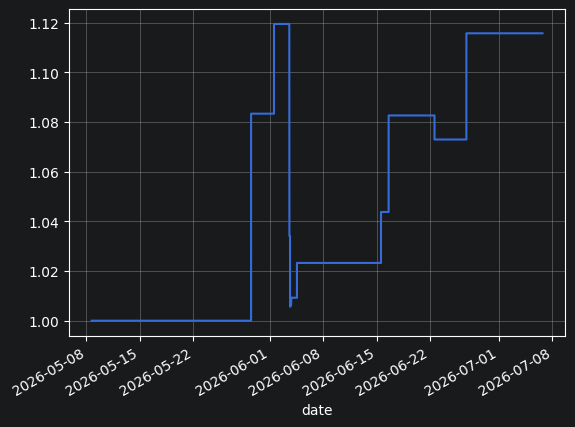

In [46]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [47]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
)
div_data

,date,amount,asset_type,notes
6,2026-07-06,0.04,BIV,$0.04 Dividend from Vanguard Intermediate Term...
7,2026-07-06,0.07,JEPI,$0.07 Dividend from JPMorgan Equity Premium In...
8,2026-07-06,0.05,BNDX,$0.05 Dividend from Vanguard Total Internation...
9,2026-07-06,0.04,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
10,2026-07-06,0.06,VGLT,$0.06 Dividend from Vanguard Long-Treasury ETF
11,2026-07-06,0.11,VMBS,$0.11 Dividend from Vanguard Mortgage-Backed S...
30,2026-07-02,0.05,CRM,$0.05 Dividend from Salesforce
66,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
67,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
68,2026-07-01,0.09,M,$0.09 Dividend from Macy's


In [48]:
div_data['amount'].sum()

np.float64(3.94)

In [49]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
81,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
66,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
88,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
84,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
227,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
78,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
67,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
79,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
98,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
69,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


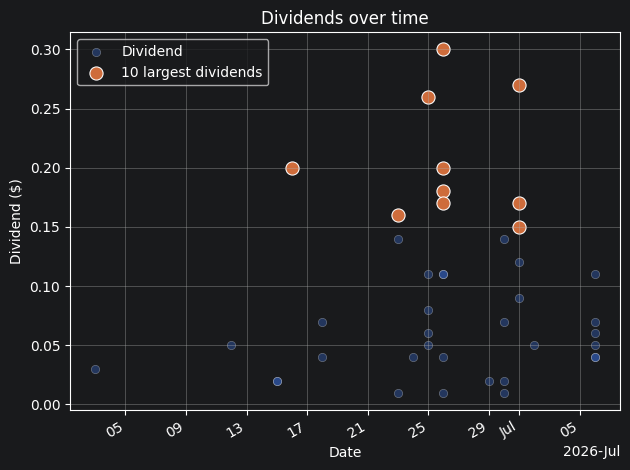

In [50]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [51]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
51,2026-07-01 14:17:44+00:00,-10.00,686.18,$10 Purchase of Vanguard S&P 500 ETF,VOO
409,2026-06-03 15:06:50+00:00,-10.00,159.33,$10 Purchase of Vanguard FTSE All World ex US ...,VSS
560,2026-06-01 13:30:11+00:00,-10.00,125.85,$10 Purchase of Vanguard Financials ETF,VFH
488,2026-06-03 13:30:00+00:00,-10.00,76.30,$10 Purchase of Vanguard Intermediate Term Bon...,BIV
451,2026-06-03 13:30:11+00:00,-10.00,390.01,$10 Purchase of Vanguard Consumer Discretionar...,VCR
319,2026-06-03 19:46:16+00:00,-10.00,275.16,$10 Purchase of Vanguard Health Care ETF,VHT
78,2026-06-26 04:00:00+00:00,0.18,NaN,$0.18 Dividend from Vanguard Real Estate ETF,VNQ
234,2026-06-15 13:30:28+00:00,-10.00,127.25,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
120,2026-06-22 13:30:14+00:00,-10.00,131.87,$10 Purchase of Vanguard Financials ETF,VFH
29,2026-07-02 13:30:00+00:00,-10.00,76.38,$10 Purchase of Vanguard Intermediate Term Bon...,BIV


In [52]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    8
VMBS    7
VOO     6
VFH     6
VDE     5
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VGLT    3
VBR     3
VCR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

In [53]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
51,2026-07-01 14:17:44+00:00,-10.00,686.18,VOO,Vanguard S&P 500 ETF
409,2026-06-03 15:06:50+00:00,-10.00,159.33,VSS,Vanguard FTSE All World ex US Small Cap ETF
560,2026-06-01 13:30:11+00:00,-10.00,125.85,VFH,Vanguard Financials ETF
488,2026-06-03 13:30:00+00:00,-10.00,76.30,BIV,Vanguard Intermediate Term Bond ETF
451,2026-06-03 13:30:11+00:00,-10.00,390.01,VCR,Vanguard Consumer Discretionary ETF
319,2026-06-03 19:46:16+00:00,-10.00,275.16,VHT,Vanguard Health Care ETF
78,2026-06-26 04:00:00+00:00,0.18,NaN,VNQ,NaN
234,2026-06-15 13:30:28+00:00,-10.00,127.25,VONG,Vanguard Russell 1000 Growth ETF
120,2026-06-22 13:30:14+00:00,-10.00,131.87,VFH,Vanguard Financials ETF
29,2026-07-02 13:30:00+00:00,-10.00,76.38,BIV,Vanguard Intermediate Term Bond ETF


In [54]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                7
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VOO         Vanguard S&P 500 ETF                           5
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BIV         Vanguard Intermediate Term Bond ETF            2
VONG        Vanguard Russell 1000 Growth ETF               2
VNQ         Vanguard Real Estate ETF                       2
VGLT        Vanguard Long-Treasury ETF                     2
BNDX        Vanguard Total International Bond ETF          2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VCR         Vanguard Consumer Discretionary ETF            2
VBR         Small Cap Value ETF Vanguard                   2
VTEB        Vanguard Tax-Exem

In [55]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VMBS,VOO,VFH,VDE,VNQ,VHT,VSS,BIV,BNDX,VTEB,VGLT,VBR,VCR,VDC,VONG,BSV
date,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
vanguard_trans_count

asset_type
VONV    8
VMBS    7
VOO     6
VFH     6
VDE     5
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VGLT    3
VBR     3
VCR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

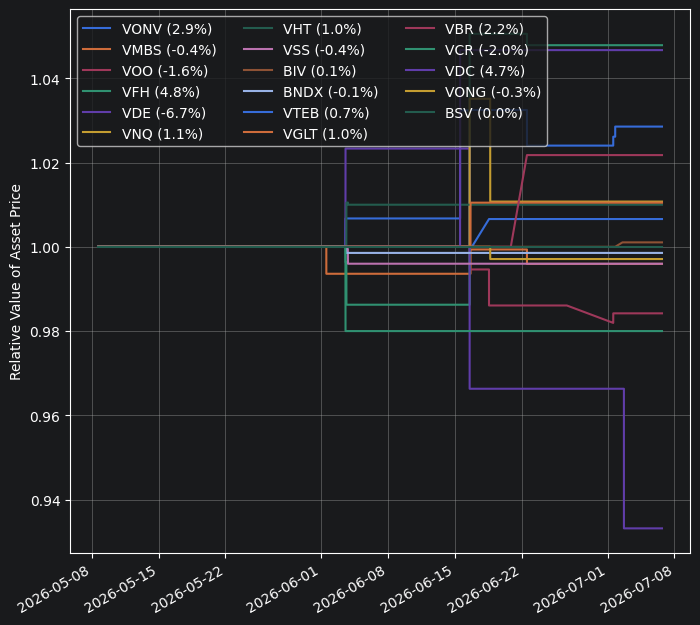

In [57]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [58]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
31,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
56,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
131,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
133,2026-06-20 12:23:07+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
144,2026-06-18 17:13:20+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
661,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
662,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
663,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
664,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [59]:
data_deposits['net_amount'].sum()

np.float64(5735.96)

In [60]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,65.0,88.245538,49.961254,1.0,50.0,100.0,100.0,200.0


In [61]:
data_deposits['net_amount'].cumsum()

31      100.00
56      200.00
131     300.00
133     400.00
144     500.00
        ...   
661    5630.96
662    5640.96
663    5690.96
664    5710.96
665    5735.96
Name: net_amount, Length: 65, dtype: float64

In [62]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
665,2026-05-26 19:39:34+00:00,25.00
664,2026-05-26 21:58:29+00:00,45.00
663,2026-05-27 00:43:01+00:00,95.00
662,2026-05-27 00:56:05+00:00,105.00
661,2026-05-27 00:56:27+00:00,205.00
...,...,...
144,2026-06-18 17:13:20+00:00,5335.96
133,2026-06-20 12:23:07+00:00,5435.96
131,2026-06-21 21:31:19+00:00,5535.96
56,2026-07-01 13:41:36+00:00,5635.96


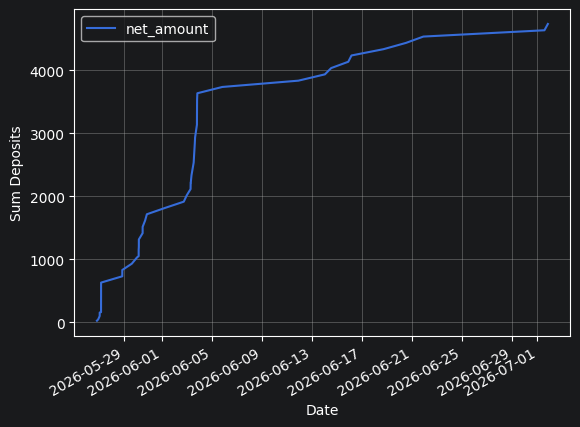

In [63]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [64]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [65]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4400.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64